# Redis API for Bitcoin Price Analytics

This notebook demonstrates the functionality of our Redis and CoinGecko API wrapper layer for Bitcoin price analytics. The API allows for:

- Connecting to Redis cloud database
- Fetching Bitcoin price data from CoinGecko API
- Storing Bitcoin data in Redis using various data structures
- Retrieving and analyzing historical price data
- Real-time price updates using Redis Pub/Sub
- Time series analysis and visualization

Refer to Redis.API.md for detailed documentation on the API design and implementation.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

## Imports

### Redis Connection 

In [2]:
# Initial cell: Import libraries and set up environment
import sys
if 'Redis_utils' in sys.modules:
    del sys.modules['Redis_utils']

import os
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime
from dotenv import load_dotenv, find_dotenv

# Load environment variables from .env file
env_path = find_dotenv(raise_error_if_not_found=True)
print(f"Found .env file at: {env_path}")
load_dotenv(env_path, override=True)

# Verify environment variables
redis_host = os.getenv('REDIS_HOST')
redis_port = os.getenv('REDIS_PORT')
redis_password = os.getenv('REDIS_PASSWORD')

print(f"Redis connection settings:")
print(f"- REDIS_HOST: {redis_host or '[not set]'}")
print(f"- REDIS_PORT: {redis_port or '[not set]'}")
print(f"- REDIS_PASSWORD: {'[set]' if redis_password else '[not set]'}")

Found .env file at: /home/jupyter/work/.env
Redis connection settings:
- REDIS_HOST: redis-14816.c98.us-east-1-4.ec2.redns.redis-cloud.com
- REDIS_PORT: 14816
- REDIS_PASSWORD: [set]


## Database Connection and Setup 

## Redis Connection and Setup

First, we'll connect to our Redis cloud instance using the connection parameters. Redis Cloud provides a fully-managed Redis service with data persistence.

In [3]:
# Cell 2: Verify Redis connection
from Redis_utils import verify_redis_connection, connect_to_redis

# Verify connection
connection_success = verify_redis_connection()

if connection_success:
    # Create Redis connection for use in subsequent cells
    redis_conn = connect_to_redis()

2025-05-16 03:13:30,970 - Redis_utils - INFO - Successfully connected to Redis at redis-14816.c98.us-east-1-4.ec2.redns.redis-cloud.com:14816
2025-05-16 03:13:31,033 - Redis_utils - INFO - Successfully connected to Redis at redis-14816.c98.us-east-1-4.ec2.redns.redis-cloud.com:14816


✅ Successfully connected to Redis at redis-14816.c98.us-east-1-4.ec2.redns.redis-cloud.com:14816


## Basic Redis Commands

This section demonstrates the native Redis commands that form the foundation of our wrapper functions. Redis provides a rich command set for different data structures like strings, hashes, lists, sets, and sorted sets. Below are examples of the most commonly used commands.

In [4]:
# Basic String Operations
# SET: Store a string value
redis_conn.set('bitcoin:latest:raw', 'This is a test value')
# GET: Retrieve a string value
value = redis_conn.get('bitcoin:latest:raw')
print(f"Retrieved string value: {value}")  

# Key Operations
# EXISTS: Check if a key exists
exists = redis_conn.exists('bitcoin:latest:raw')
print(f"Key exists: {exists}")
# TTL: Get time-to-live for a key
ttl = redis_conn.ttl('bitcoin:latest:raw')
print(f"TTL for key: {ttl} seconds")
# EXPIRE: Set expiration time for a key
redis_conn.expire('bitcoin:latest:raw', 3600)  # expire in 1 hour
print(f"Set expiration, new TTL: {redis_conn.ttl('bitcoin:latest:raw')} seconds")

# Hash Operations
# HSET: Store hash fields
redis_conn.hset('bitcoin:summary', mapping={
    'price': '96650',
    'market_cap': '1919379356304.60',
    'change_24h': '2.89'
})
# HGETALL: Get all fields in a hash
summary = redis_conn.hgetall('bitcoin:summary')
print("Hash data:")
for key, value in summary.items():
    print(f"  {key}: {value}")  


# List Operations
# LPUSH/RPUSH: Add elements to a list
redis_conn.lpush('bitcoin:updates', 'update1')
redis_conn.rpush('bitcoin:updates', 'update2')
# LRANGE: Get range of elements from a list
updates = redis_conn.lrange('bitcoin:updates', 0, -1)
print("List data:", updates) 

# Set Operations
# SADD: Add members to a set
redis_conn.sadd('bitcoin:sources', 'coingecko', 'binance', 'coinbase')
# SMEMBERS: Get all members in a set
sources = redis_conn.smembers('bitcoin:sources')
print("Set data:", list(sources))  

# Sorted Set Operations
# ZADD: Add members to a sorted set
redis_conn.zadd('bitcoin:prices:hourly', {'2025-05-01T12:00': 96500, '2025-05-01T13:00': 96700})
# ZRANGE: Get range of elements from sorted set
prices = redis_conn.zrange('bitcoin:prices:hourly', 0, -1, withscores=True)
print("Sorted set data:", prices) 

Retrieved string value: This is a test value
Key exists: 1
TTL for key: -1 seconds
Set expiration, new TTL: 3600 seconds
Hash data:
  price: 96650
  market_cap: 1919379356304.60
  change_24h: 2.89
List data: ['update1', 'update1', 'update1', 'update1', 'update1', 'update2', 'update2', 'update2', 'update2', 'update2']
Set data: ['coinbase', 'coingecko', 'binance']
Sorted set data: [('2025-05-01T12:00', 96500.0), ('2025-05-01T13:00', 96700.0)]


## Creaste Databae Table

In [5]:
# Key patterns we'll use:
# - bitcoin:current_price:{currency} - Stores the current price
# - bitcoin:data:{currency} - Stores the latest data as a hash
# - bitcoin:price_history:{currency} - Stores all price data as a sorted set
# - bitcoin:last_updated - Timestamp of last update

# Let's verify if any of these keys already exist
key_patterns = [
    "bitcoin:current_price:usd",
    "bitcoin:data:usd",
    "bitcoin:price_history:usd",
    "bitcoin:last_updated"
]

print("Checking existing Redis keys:")
for key in key_patterns:
    exists = redis_conn.exists(key)
    if exists:
        # For sorted sets, count the number of elements
        if "price_history" in key:
            count = redis_conn.zcount(key, "-inf", "+inf")
            print(f"- {key}: EXISTS with {count} data points")
        else:
            print(f"- {key}: EXISTS")
    else:
        print(f"- {key}: DOES NOT EXIST")

Checking existing Redis keys:
- bitcoin:current_price:usd: EXISTS
- bitcoin:data:usd: EXISTS
- bitcoin:price_history:usd: EXISTS with 530 data points
- bitcoin:last_updated: EXISTS


## Fetch and Store Bitcoin Data

Now we'll fetch Bitcoin price data from the CoinGecko API and store it in Redis. We'll use various Redis data structures:

- Strings for current price
- Hashes for complete data points
- Sorted Sets for time series data

This demonstrates how Redis can be used for different data access patterns.

### Data Fetching 

In [6]:
# Import the required functions
from Redis_utils import fetch_bitcoin_price, fetch_bitcoin_historical

# Fetch current Bitcoin price
currency = 'usd'
price_data = fetch_bitcoin_price(currency)

# Display current price data
print(f"Current Bitcoin price: ${price_data[currency]:,.2f}")
print(f"24-hour change: {price_data[f'{currency}_24h_change']:.2f}%")
print(f"Market cap: ${price_data[f'{currency}_market_cap']:,.0f}")
print(f"24-hour volume: ${price_data[f'{currency}_24h_vol']:,.0f}")
print(f"Last updated: {datetime.fromtimestamp(price_data['last_updated_at'])}")

# Fetch historical data for the past 7 days
historical_data = fetch_bitcoin_historical(days=7, currency=currency)
print(f"Retrieved historical data with {len(historical_data['prices'])} price points")

# Show sample of historical data
sample_data = historical_data['prices'][:5]
for timestamp_ms, price in sample_data:
    dt = datetime.fromtimestamp(timestamp_ms/1000)
    print(f"{dt}: ${price:,.2f}")

2025-05-16 03:13:31,640 - Redis_utils - INFO - Successfully fetched Bitcoin price: 104133 USD
2025-05-16 03:13:31,794 - Redis_utils - INFO - Successfully fetched historical Bitcoin data for the last 7 days


Current Bitcoin price: $104,133.00
24-hour change: 1.10%
Market cap: $2,068,625,733,450
24-hour volume: $33,904,464,146
Last updated: 2025-05-16 03:13:07
Retrieved historical data with 168 price points
2025-05-09 03:04:17.158000: $102,602.61
2025-05-09 04:04:17.844000: $102,431.39
2025-05-09 05:04:42.226000: $102,735.24
2025-05-09 06:04:20.120000: $102,936.71
2025-05-09 07:37:44.828000: $103,654.43


## Store Data in Redis

Fetch Historical Bitcoin Data

Let's fetch some historical Bitcoin price data from CoinGecko API and store it in Redis for analysis.

In [7]:
# Import the required functions
from Redis_utils import store_bitcoin_price

# Store current price data in Redis
store_success = store_bitcoin_price(redis_conn, price_data, currency)
print(f"Current price data stored in Redis: {store_success}")

# For historical data, we need to process and store each data point
# Let's store the last 7 days of data

# Function to store historical data
def store_historical_data(redis_conn, historical_data, currency='usd'):
    count = 0
    for timestamp_ms, price in historical_data['prices']:
        # Convert timestamp to seconds
        timestamp = int(timestamp_ms / 1000)
        
        # Create a simple data structure (only price, no market cap etc.)
        data = {
            currency: price,
            'timestamp': timestamp
        }
        
        # Add to time series (using sorted set with timestamp as score)
        redis_conn.zadd(
            f"bitcoin:price_history:{currency}", 
            {json.dumps(data): timestamp}
        )
        count += 1
    
    return count

# We need json module
import json

# Store historical data
stored_count = store_historical_data(redis_conn, historical_data, currency)
print(f"Stored {stored_count} historical data points in Redis")

# Verify the data is stored
count = redis_conn.zcount(f"bitcoin:price_history:{currency}", "-inf", "+inf")
print(f"Total data points in Redis time series: {count}")

2025-05-16 03:13:31,900 - Redis_utils - INFO - Successfully stored Bitcoin price data in Redis


Current price data stored in Redis: True
Stored 168 historical data points in Redis
Total data points in Redis time series: 532


## Redis Data Structures for Bitcoin Analytics

In [8]:
# Import the required function
from Redis_utils import fetch_bitcoin_price

# Fetch current Bitcoin price data
bitcoin_data = fetch_bitcoin_price(currency='usd')
print(f"Current Bitcoin price: ${bitcoin_data['usd']:,.2f}")

2025-05-16 03:13:33,796 - Redis_utils - INFO - Successfully fetched Bitcoin price: 104133 USD


Current Bitcoin price: $104,133.00


In [9]:
# Example 1: Using Strings for latest Bitcoin price
# String is perfect for simple key-value storage like current price
latest_price_key = "bitcoin:current_price:usd"
redis_conn.set(latest_price_key, str(bitcoin_data['usd']))
redis_conn.expire(latest_price_key, 60)  # Expire after 60 seconds to ensure freshness
print(f"Latest price stored as string: {redis_conn.get(latest_price_key)} USD")  

# Example 2: Using Hashes for complete price data point
# Hash is ideal for storing objects with multiple fields
hash_key = "bitcoin:latest_data"
redis_conn.hset(hash_key, mapping={
    "price": str(bitcoin_data['usd']),
    "market_cap": str(bitcoin_data['usd_market_cap']),
    "volume": str(bitcoin_data.get('usd_24h_vol', 0)),
    "change_24h": str(bitcoin_data['usd_24h_change']),
    "timestamp": str(int(time.time()))
})
hash_data = redis_conn.hgetall(hash_key)
print("Hash data for latest Bitcoin info:")
for key, value in hash_data.items():
    print(f"  {key}: {value}")  

# Example 3: Using Sorted Sets for time series data
# Sorted set with timestamp score is perfect for time series data
ts_key = "bitcoin:price:history"
# Add current timestamp and price to the sorted set
timestamp = int(time.time())
redis_conn.zadd(ts_key, {str(timestamp): bitcoin_data['usd']})
# Get the latest 5 data points
latest_points = redis_conn.zrevrange(ts_key, 0, 4, withscores=True)
print("Latest price history from sorted set:")
for value, score in latest_points:
    ts = datetime.fromtimestamp(float(value))  
    print(f"  {ts}: ${score:,.2f}")

# Example 4: Using Lists for recent updates log
# List is great for activity logs or recent updates
updates_key = "bitcoin:price:updates:log"
update_message = f"Price updated to ${bitcoin_data['usd']:,.2f} at {datetime.now()}"
redis_conn.lpush(updates_key, update_message)
redis_conn.ltrim(updates_key, 0, 9)  # Keep only 10 most recent updates
recent_updates = redis_conn.lrange(updates_key, 0, -1)
print("Recent price update log:")
for update in recent_updates:
    print(f"  {update}")  

# Example 5: Using Sets for tracking data sources
# Set is useful for unique collections like data sources
sources_key = "bitcoin:data:sources"
redis_conn.sadd(sources_key, "coingecko_api", "realtime_feed", "user_submission")
sources = redis_conn.smembers(sources_key)
print("Data sources being tracked:")
for source in sources:
    print(f"  {source}") 

Latest price stored as string: 104133 USD
Hash data for latest Bitcoin info:
  price: 104133
  market_cap: 2068625733450.205
  volume: 33904464145.864716
  change_24h: 1.102836711945996
  timestamp: 1747365213
Latest price history from sorted set:
  2025-05-16 03:10:47: $104,153.00
  2025-05-16 03:10:43: $104,153.00
  2025-05-16 03:13:33: $104,133.00
  2025-05-15 21:13:15: $103,212.00
Recent price update log:
  Price updated to $104,133.00 at 2025-05-16 03:13:33.953021
  Price updated to $104,153.00 at 2025-05-15 23:10:47.799378
  Price updated to $104,153.00 at 2025-05-15 23:10:43.599439
  Price updated to $103,212.00 at 2025-05-15 17:13:15.695086
Data sources being tracked:
  realtime_feed
  coingecko_api
  user_submission


### Get price history from Redis

In [10]:
# Import the required functions
from Redis_utils import get_price_history, get_price_dataframe

# Calculate time range for 7 days
end_time = int(time.time())
start_time = end_time - (7 * 24 * 3600)  # 7 days in seconds

print(f"Retrieving Bitcoin price data from {datetime.fromtimestamp(start_time)} to {datetime.fromtimestamp(end_time)}")

# Get price history from Redis
price_history = get_price_history(redis_conn, start_time, end_time, currency)
print(f"Retrieved {len(price_history)} data points from Redis")

# Convert to DataFrame for analysis
df = get_price_dataframe(price_history, currency)
print(f"Data range: {df.index.min()} to {df.index.max()}")

# Display the first few rows
print("\nSample data:")
display(df.head())

# Display basic statistics
print("\nBasic statistics:")
display(df.describe())

# Calculate hourly resampled data (for cleaner visualization)
df_hourly = df.resample('1H').mean()
print(f"\nResampled to hourly data with {len(df_hourly)} data points")
display(df_hourly.head())

2025-05-16 03:13:34,104 - Redis_utils - INFO - Retrieved 349 Bitcoin price records from history


Retrieving Bitcoin price data from 2025-05-09 03:13:34 to 2025-05-16 03:13:34
Retrieved 349 data points from Redis
Data range: 2025-05-09 04:04:17 to 2025-05-16 03:13:31

Sample data:


,timestamp,price,market_cap,volume_24h,change_24h
datetime,,,,,
2025-05-09 04:04:17,1746763457,102431.385938,NaN,NaN,NaN
2025-05-09 04:04:17,1746763457,102431.385938,2.033784e+12,4.869599e+10,0.0
2025-05-09 05:04:42,1746767082,102735.235420,NaN,NaN,NaN
2025-05-09 05:04:42,1746767082,102735.235420,2.040306e+12,4.764232e+10,0.0
2025-05-09 06:04:20,1746770660,102936.707481,NaN,NaN,NaN



Basic statistics:


,timestamp,price,market_cap,volume_24h,change_24h
count,3.490000e+02,349.000000,1.780000e+02,1.780000e+02,178.000000
mean,1.747078e+09,103446.986485,2.054533e+12,3.327692e+10,0.005922
std,1.796521e+05,692.608446,1.372854e+10,8.371357e+09,0.184514
min,1.746763e+09,101749.060160,2.018175e+12,1.946456e+10,-0.487053
25%,1.746922e+09,102977.496819,2.046792e+12,2.745672e+10,0.000000
50%,1.747080e+09,103541.329914,2.055330e+12,3.103759e+10,0.000000
75%,1.747236e+09,103961.025180,2.064250e+12,3.704457e+10,0.000000
max,1.747365e+09,104778.262185,2.080432e+12,5.685568e+10,1.126512



Resampled to hourly data with 168 data points


,timestamp,price,market_cap,volume_24h,change_24h
datetime,,,,,
2025-05-09 04:00:00,1.746763e+09,102431.385938,2.033784e+12,4.869599e+10,0.0
2025-05-09 05:00:00,1.746767e+09,102735.235420,2.040306e+12,4.764232e+10,0.0
2025-05-09 06:00:00,1.746771e+09,102936.707481,2.044285e+12,4.596156e+10,0.0
2025-05-09 07:00:00,1.746776e+09,103654.432069,2.058160e+12,4.688908e+10,0.0
2025-05-09 08:00:00,1.746778e+09,103775.851994,2.063074e+12,4.949942e+10,0.0


## Redis Operations Explained

This section provides detailed explanations of what's happening with Redis at each step of our Bitcoin data pipeline. Understanding these operations helps in optimizing performance and designing scalable data workflows.

In [11]:
# 1. Storing current Bitcoin price
current_price = bitcoin_data['usd']
print(f"Current Bitcoin price: ${current_price:,.2f}")

# Explanation of what happens in Redis:
print("Redis operation explanation - Storing current price:")
print("1. When we store the current price using store_bitcoin_price() function:")
print("   a. SET bitcoin:current:price <price>  - Stores the current price as a string")
print("   b. HMSET bitcoin:latest <multiple fields> - Stores complete data point as hash")
print("   c. ZADD bitcoin:price:history <timestamp> <price> - Adds to time series (sorted set)")
print("   d. SET bitcoin:last_updated <timestamp> - Updates last updated timestamp")
print("   e. PUBLISH bitcoin_price_updates <data> - Publishes update to subscribers")
print("2. Redis assigns each key to a memory location")
print("3. Redis updates any relevant indexes for sorted sets")
print("4. Redis propagates the changes to subscribers if any\n")

# 2. Retrieving time-series data for analysis
print("Redis operation explanation - Retrieving time series data:")
start_time = int(time.time()) - (24 * 3600)  # 24 hours ago
end_time = int(time.time())
print(f"Time range: {datetime.fromtimestamp(start_time)} to {datetime.fromtimestamp(end_time)}")
print("1. When we retrieve price history using get_price_history() function:")
print("   a. ZRANGEBYSCORE bitcoin:price:history <start_time> <end_time> - Gets time-range data")
print("   b. Redis searches through the sorted set using a skip list data structure")
print("   c. Skip list provides O(log N) time complexity for range queries")
print("   d. Redis returns only the elements within the specified score range")
print("   e. Data is returned as an array of (value, score) tuples\n")

# 3. Creating moving averages
print("Redis operation explanation - Calculating moving averages:")
print("1. Retrieve raw time series data from Redis")
print("2. Convert to pandas DataFrame for analysis")
print("3. The calculate_moving_average() function:")
print("   a. Uses pandas rolling window function")
print("   b. Computes average over specified window size")
print("   c. Results could be stored back in Redis as a separate time series")
print("   d. This allows for pre-computation of common analytics\n")

# 4. Publish-Subscribe pattern
print("Redis operation explanation - Pub/Sub system:")
print("1. When a new price update occurs:")
print("   a. PUBLISH bitcoin_price_updates <data> - Sends message to channel")
print("2. For subscribers:")
print("   a. SUBSCRIBE bitcoin_price_updates - Listens for updates")
print("   b. Redis maintains a list of clients subscribed to each channel")
print("   c. When a message is published, Redis pushes it to all subscribers")
print("   d. This enables real-time price monitoring applications")

Current Bitcoin price: $104,133.00
Redis operation explanation - Storing current price:
1. When we store the current price using store_bitcoin_price() function:
   a. SET bitcoin:current:price <price>  - Stores the current price as a string
   b. HMSET bitcoin:latest <multiple fields> - Stores complete data point as hash
   c. ZADD bitcoin:price:history <timestamp> <price> - Adds to time series (sorted set)
   d. SET bitcoin:last_updated <timestamp> - Updates last updated timestamp
   e. PUBLISH bitcoin_price_updates <data> - Publishes update to subscribers
2. Redis assigns each key to a memory location
3. Redis updates any relevant indexes for sorted sets
4. Redis propagates the changes to subscribers if any

Redis operation explanation - Retrieving time series data:
Time range: 2025-05-15 03:13:34 to 2025-05-16 03:13:34
1. When we retrieve price history using get_price_history() function:
   a. ZRANGEBYSCORE bitcoin:price:history <start_time> <end_time> - Gets time-range data
   b. R

## Retrieve and Analyze Bitcoin Data

Now we'll retrieve the stored Bitcoin price data from Redis and perform some basic analysis.

### Basic Visualization for 7-Day Price Time Series Plot

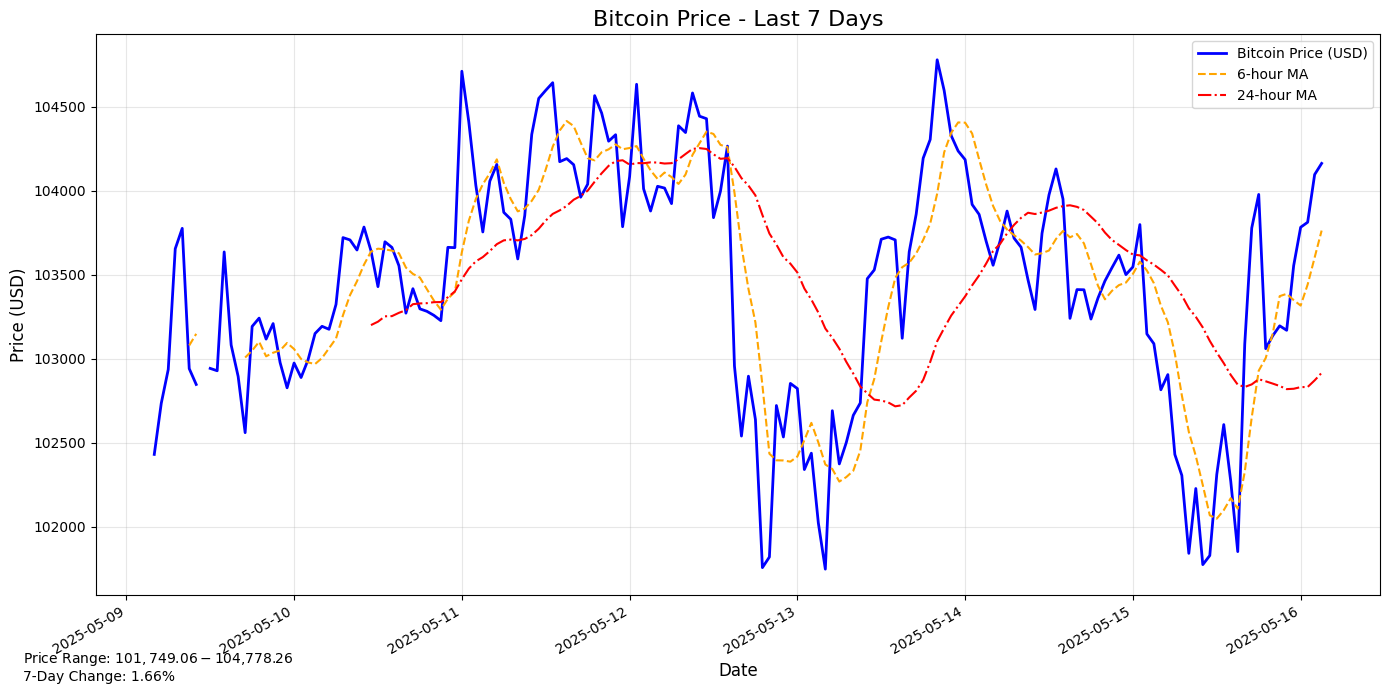

7-Day Bitcoin Price Summary:
Starting Price: $102,431.39
Current Price: $104,133.00
Change: $1,701.61 (1.66%)
Low: $101,749.06
High: $104,778.26
Volatility (Std Dev): $692.61


In [12]:
# Create a visualization of the 7-day price history
plt.figure(figsize=(14, 7))

# Plot price data (use hourly resampled data for cleaner plot)
plt.plot(df_hourly.index, df_hourly['price'], label='Bitcoin Price (USD)', color='blue', linewidth=2)

# Add moving averages
df_hourly['MA_6h'] = df_hourly['price'].rolling(window=6).mean()  # 6-hour moving average
df_hourly['MA_24h'] = df_hourly['price'].rolling(window=24).mean()  # 24-hour moving average

plt.plot(df_hourly.index, df_hourly['MA_6h'], label='6-hour MA', color='orange', linestyle='--')
plt.plot(df_hourly.index, df_hourly['MA_24h'], label='24-hour MA', color='red', linestyle='-.')

# Add labels and title
plt.title('Bitcoin Price - Last 7 Days', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Format x-axis dates
plt.gcf().autofmt_xdate()

# Calculate key statistics
min_price = df['price'].min()
max_price = df['price'].max()
first_price = df['price'].iloc[0] if not df.empty else 0
last_price = df['price'].iloc[-1] if not df.empty else 0
percent_change = ((last_price - first_price) / first_price * 100) if first_price != 0 else 0

# Add text with price information
info_text = f"Price Range: ${min_price:,.2f} - ${max_price:,.2f}\n"
info_text += f"7-Day Change: {percent_change:.2f}%"
plt.figtext(0.02, 0.02, info_text, fontsize=10)

# Show plot
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"7-Day Bitcoin Price Summary:")
print(f"Starting Price: ${first_price:,.2f}")
print(f"Current Price: ${last_price:,.2f}")
print(f"Change: ${last_price-first_price:,.2f} ({percent_change:.2f}%)")
print(f"Low: ${min_price:,.2f}")
print(f"High: ${max_price:,.2f}")
print(f"Volatility (Std Dev): ${df['price'].std():,.2f}")

2025-05-16 03:13:35,455 - Redis_utils - INFO - Basic Statistics:
2025-05-16 03:13:35,458 - Redis_utils - INFO - Mean price: 103446.99
2025-05-16 03:13:35,465 - Redis_utils - INFO - Median price: 103541.33
2025-05-16 03:13:35,467 - Redis_utils - INFO - Min price: 101749.06
2025-05-16 03:13:35,469 - Redis_utils - INFO - Max price: 104778.26
2025-05-16 03:13:35,475 - Redis_utils - INFO - Price range: 3029.20
2025-05-16 03:13:35,477 - Redis_utils - INFO - Standard deviation: 692.61
2025-05-16 03:13:35,487 - Redis_utils - INFO - 1-hour change: 1.19%
2025-05-16 03:13:35,492 - Redis_utils - INFO - Detected 16 price anomalies



Detailed anomaly detection:
Detected 16 price anomalies


,timestamp,price,market_cap,volume_24h,change_24h
datetime,,,,,
2025-05-12 19:07:20,1747076840,101758.108960,NaN,NaN,NaN
2025-05-12 19:07:20,1747076840,101758.108960,2.018175e+12,4.366702e+10,0.0
2025-05-12 20:04:59,1747080299,101821.248197,NaN,NaN,NaN
2025-05-12 20:04:59,1747080299,101821.248197,2.022710e+12,4.456198e+10,0.0
2025-05-13 03:02:31,1747105351,102023.670648,NaN,NaN,NaN
2025-05-13 03:02:31,1747105351,102023.670648,2.025874e+12,4.428011e+10,0.0
2025-05-13 04:04:41,1747109081,101749.060160,NaN,NaN,NaN
2025-05-13 04:04:41,1747109081,101749.060160,2.020517e+12,4.518025e+10,0.0
2025-05-15 08:04:47,1747296287,101842.963022,NaN,NaN,NaN


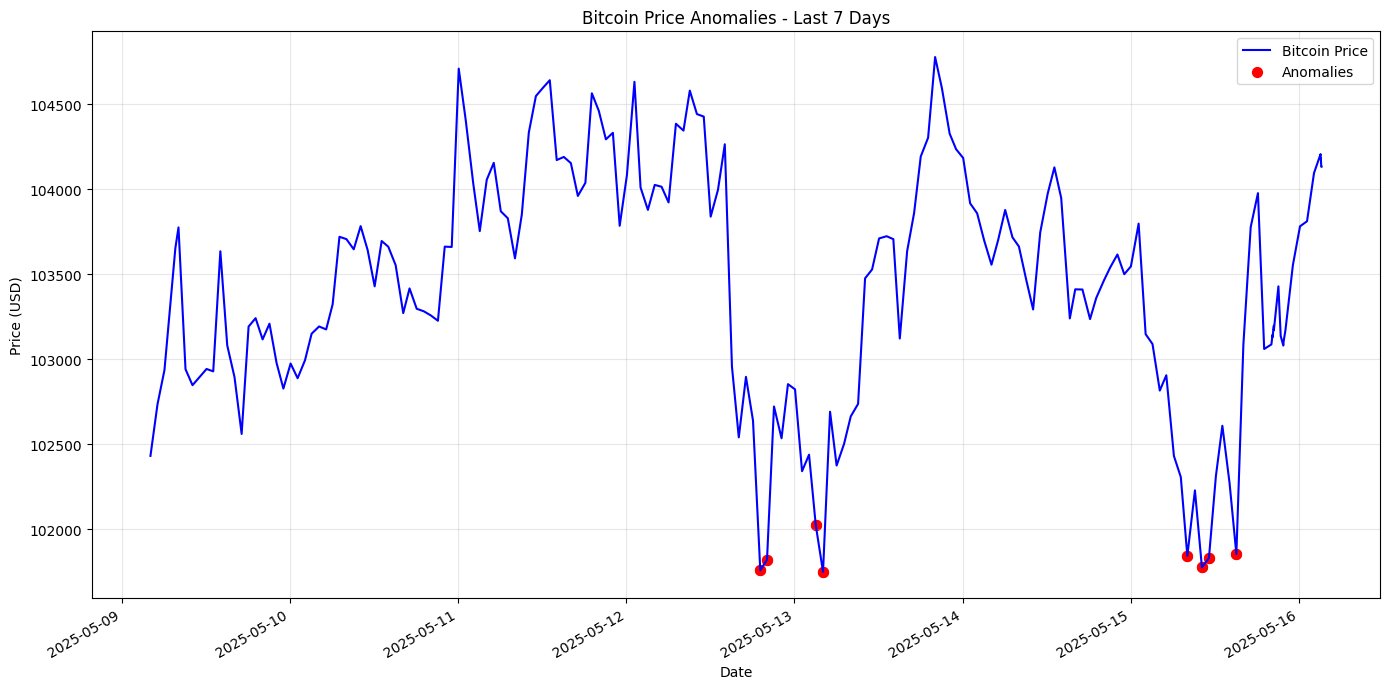

In [13]:
# Import additional analysis functions
from Redis_utils import analyze_price_data, detect_price_anomalies

# Perform full price data analysis
anomalies = analyze_price_data(df)

# Find anomalies in the data
print("\nDetailed anomaly detection:")
anomaly_points = df[anomalies]
if len(anomaly_points) > 0:
    print(f"Detected {len(anomaly_points)} price anomalies")
    display(anomaly_points)
    
    # Plot anomalies
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df['price'], label='Bitcoin Price', color='blue')
    plt.scatter(anomaly_points.index, anomaly_points['price'], 
                color='red', marker='o', s=50, label='Anomalies')
    plt.title('Bitcoin Price Anomalies - Last 7 Days')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()
else:
    print("No anomalies detected in the price data")